1. Title and objective

# CICIoMT2024 - Exploratory Data Analysis (EDA)

## Objective
The purpose of this notebook is to perform exploratory data analysis on the CICIoMT2024 dataset after the initial loading and inspection stage. The analysis focuses on understanding class imbalance, examining feature distributions, identifying feature relationships, comparing attack categories, and generating visual insights that will support later preprocessing and machine learning modeling.

This notebook uses the merged dataset produced in Notebook 1.

2. Imports

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

3. Display and plot settings

In [2]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 1000)

plt.style.use("default")
sns.set_theme(style="whitegrid")

4. Load the merged dataset

## Load merged dataset
The merged dataset created in Notebook 1 is loaded for exploratory analysis.

In [3]:
DATA_PATH = Path("../data/interim/ciciomt2024_merged.csv")
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (3385313, 91)


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack Name,Label,source_file,attack_label,attack_category,target_binary,target_multiclass_full,target_multiclass_grouped
0,34.173.20.6-192.168.137.234-443-58644-6,34.173.20.6,443,192.168.137.234,58644,6,14/09/2023 09:24:26 AM,14746364,6,0,63.0,0.0,39.0,0.0,10.500000,16.944025,0.0,0.0,0.00000,0.000000,4.272240,0.406880,2.949273e+06,6.558360e+06,14681116.0,2.0,14746364.0,2.949273e+06,6.558360e+06,14681116.0,2.0,0.0,0.000000,0.000000,0.0,0.0,0,0,0,0,192,0,0.406880,0.000000,0.0,39.0,9.000000,15.968719,255.000000,1,0,1,2,6,0,0,0,0.0,10.500000,10.500000,0.00000,0,0,0,0,0,0,6,63,0,0,331,0,2,32,0.0,0.0,0.0,0.0,14681116.0,0.000000,14681116.0,14681116.0,Benign Traffic,0,Benign Traffic.csv,Benign Traffic,Benign,0,Benign Traffic,Benign
1,34.173.20.6-192.168.137.234-443-58646-6,34.173.20.6,443,192.168.137.234,58646,6,14/09/2023 09:24:41 AM,60102110,18,0,4135.0,0.0,1408.0,0.0,229.722222,490.460505,0.0,0.0,0.00000,0.000000,68.799581,0.299490,3.535418e+06,6.531527e+06,15061923.0,1.0,60102110.0,3.535418e+06,6.531527e+06,15061923.0,1.0,0.0,0.000000,0.000000,0.0,0.0,0,0,0,0,584,0,0.299490,0.000000,0.0,1408.0,217.631579,479.546685,229965.023392,1,1,1,7,18,0,0,0,0.0,229.722222,229.722222,0.00000,0,0,0,4072,6,56313,4,1033,0,0,43648,0,8,32,219123.0,0.0,219123.0,219123.0,14957706.0,190543.248665,15061923.0,14672051.0,Benign Traffic,0,Benign Traffic.csv,Benign Traffic,Benign,0,Benign Traffic,Benign
2,52.40.210.103-192.168.137.40-18665-60378-6,52.40.210.103,18665,192.168.137.40,60378,6,14/09/2023 09:24:14 AM,90106769,9,0,1164.0,0.0,194.0,0.0,129.333333,97.000000,0.0,0.0,0.00000,0.000000,12.918008,0.099882,1.126335e+07,1.538550e+07,30049066.0,4.0,90106769.0,1.126335e+07,1.538550e+07,30049066.0,4.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,312,0,0.099882,0.000000,0.0,194.0,135.800000,93.710903,8781.733333,0,0,0,6,9,0,0,0,0.0,150.888889,129.333333,0.00000,0,0,0,0,0,0,3,388,0,0,850,0,5,32,582529.0,0.0,582529.0,582529.0,29841412.0,319090.538141,30049066.0,29473997.0,Benign Traffic,0,Benign Traffic.csv,Benign Traffic,Benign,0,Benign Traffic,Benign
3,10.0.0.3-10.0.0.254-44505-1883-6,10.0.0.3,44505,10.0.0.254,1883,6,14/09/2023 09:24:15 AM,119998980,123,123,2157.0,4.0,20.0,0.0,17.536585,2.309257,2.0,0.0,0.03252,0.253983,18.008486,2.050017,4.897918e+05,5.001567e+05,1008475.0,29.0,119998868.0,9.835973e+05,1.271666e+05,1008531.0,2539.0,119998918.0,983597.688525,127738.757478,1042745.0,104.0,1,0,0,0,3936,3936,1.025009,1.025009,0.0,20.0,8.821862,8.922922,79.618544,0,0,0,123,246,0,0,0,1.0,8.857724,17.536585,0.03252,0,0,0,72,4,24,2,38,2,0,502,64,120,32,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign Traffic,0,Benign Traffic.csv,Benign Traffic,Benign,0,Benign Traffic,Benign
4,10.0.0.7-10.0.0.254-

5. Basic overview

## Basic overview
This section provides a quick overview of the dataset structure and target variables.

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Rows: 3385313
Columns: 91

Column names:
['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Co

In [5]:
print("Target columns summary:")
print("\nBinary target distribution:")
print(df["target_binary"].value_counts())

print("\nBinary target labels:")
print(df["target_binary"].map({0: "Benign", 1: "Attack"}).value_counts())

print("\nGrouped multiclass distribution:")
print(df["target_multiclass_grouped"].value_counts())

print("\nFull multiclass distribution:")
print(df["target_multiclass_full"].value_counts())

Target columns summary:

Binary target distribution:
target_binary
1    3352693
0      32620
Name: count, dtype: int64

Binary target labels:
target_binary
Attack    3352693
Benign      32620
Name: count, dtype: int64

Grouped multiclass distribution:
target_multiclass_grouped
DoS            2112138
MQTT Attack     655143
Recon           579231
Benign           32620
DDoS              5128
Spoofing          1053
Name: count, dtype: int64

Full multiclass distribution:
target_multiclass_full
DoS TCP Flood               2106916
Recon Port Scan              485522
MQTT DDoS Publish Flood      413913
MQTT DoS Connect Flood       238031
Recon OS Scan                 85317
Benign Traffic                32620
Recon Vulnerability Scan       8321
DoS UDP Flood                  3115
DDoS UDP Flood                 2576
DDoS ICMP Flood                2552
MQTT Malformed                 2246
DoS ICMP Flood                 2107
MITM ARP Spoofing              1053
MQTT DoS Publish Flood          953


6. Binary target distribution

## Binary class distribution
The binary target is highly imbalanced, with attack traffic strongly dominating benign traffic.

In [6]:
binary_counts = df["target_binary"].map({0: "Benign", 1: "Attack"}).value_counts()
binary_counts

target_binary
Attack    3352693
Benign      32620
Name: count, dtype: int64

In [7]:
binary_pct = (binary_counts / binary_counts.sum()) * 100
binary_pct

target_binary
Attack    99.036426
Benign     0.963574
Name: count, dtype: float64

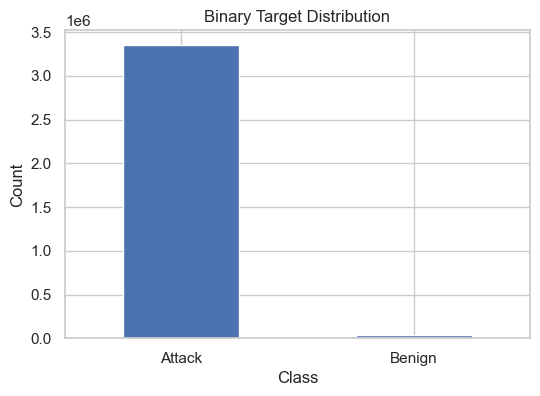

In [8]:
plt.figure(figsize=(6, 4))
binary_counts.plot(kind="bar")
plt.title("Binary Target Distribution")
plt.ylabel("Count")
plt.xlabel("Class")
plt.xticks(rotation=0)
plt.show()

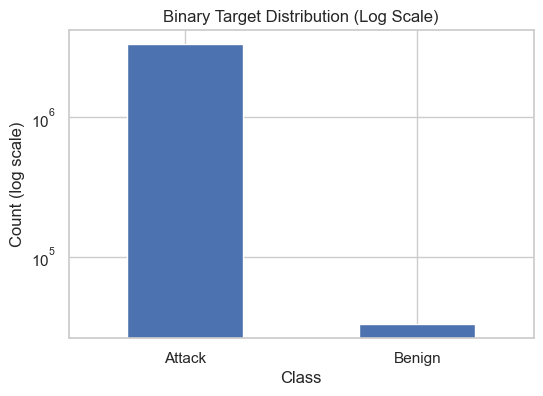

In [9]:
plt.figure(figsize=(6, 4))
binary_counts.plot(kind="bar", logy=True)
plt.title("Binary Target Distribution (Log Scale)")
plt.ylabel("Count (log scale)")
plt.xlabel("Class")
plt.xticks(rotation=0)
plt.show()

7. Grouped attack category distribution

## Grouped attack-category distribution
To obtain a more interpretable multiclass view, detailed attacks are grouped into broader categories.

In [10]:
grouped_counts = df["target_multiclass_grouped"].value_counts()
grouped_counts

target_multiclass_grouped
DoS            2112138
MQTT Attack     655143
Recon           579231
Benign           32620
DDoS              5128
Spoofing          1053
Name: count, dtype: int64

In [11]:
grouped_pct = (grouped_counts / grouped_counts.sum()) * 100
grouped_pct

target_multiclass_grouped
DoS            62.391218
MQTT Attack    19.352509
Recon          17.110117
Benign          0.963574
DDoS            0.151478
Spoofing        0.031105
Name: count, dtype: float64

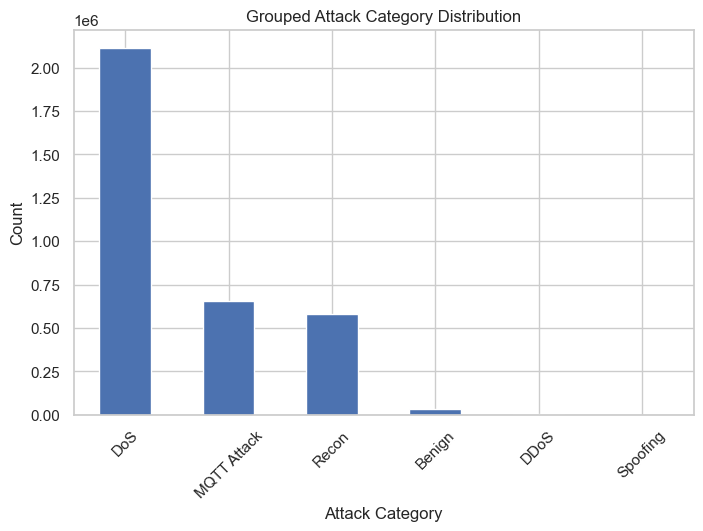

In [12]:
plt.figure(figsize=(8, 5))
grouped_counts.plot(kind="bar")
plt.title("Grouped Attack Category Distribution")
plt.ylabel("Count")
plt.xlabel("Attack Category")
plt.xticks(rotation=45)
plt.show()

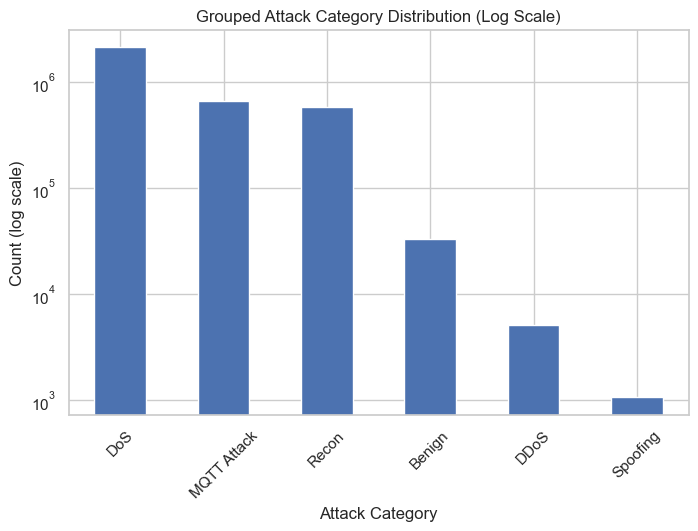

In [13]:
plt.figure(figsize=(8, 5))
grouped_counts.plot(kind="bar", logy=True)
plt.title("Grouped Attack Category Distribution (Log Scale)")
plt.ylabel("Count (log scale)")
plt.xlabel("Attack Category")
plt.xticks(rotation=45)
plt.show()

8. Full attack-label distribution

## Detailed attack-label distribution
This section presents the full multiclass distribution at the attack-type level.

In [14]:
full_counts = df["target_multiclass_full"].value_counts()
full_counts

target_multiclass_full
DoS TCP Flood               2106916
Recon Port Scan              485522
MQTT DDoS Publish Flood      413913
MQTT DoS Connect Flood       238031
Recon OS Scan                 85317
Benign Traffic                32620
Recon Vulnerability Scan       8321
DoS UDP Flood                  3115
DDoS UDP Flood                 2576
DDoS ICMP Flood                2552
MQTT Malformed                 2246
DoS ICMP Flood                 2107
MITM ARP Spoofing              1053
MQTT DoS Publish Flood          953
Recon Ping Sweep                 71
Name: count, dtype: int64

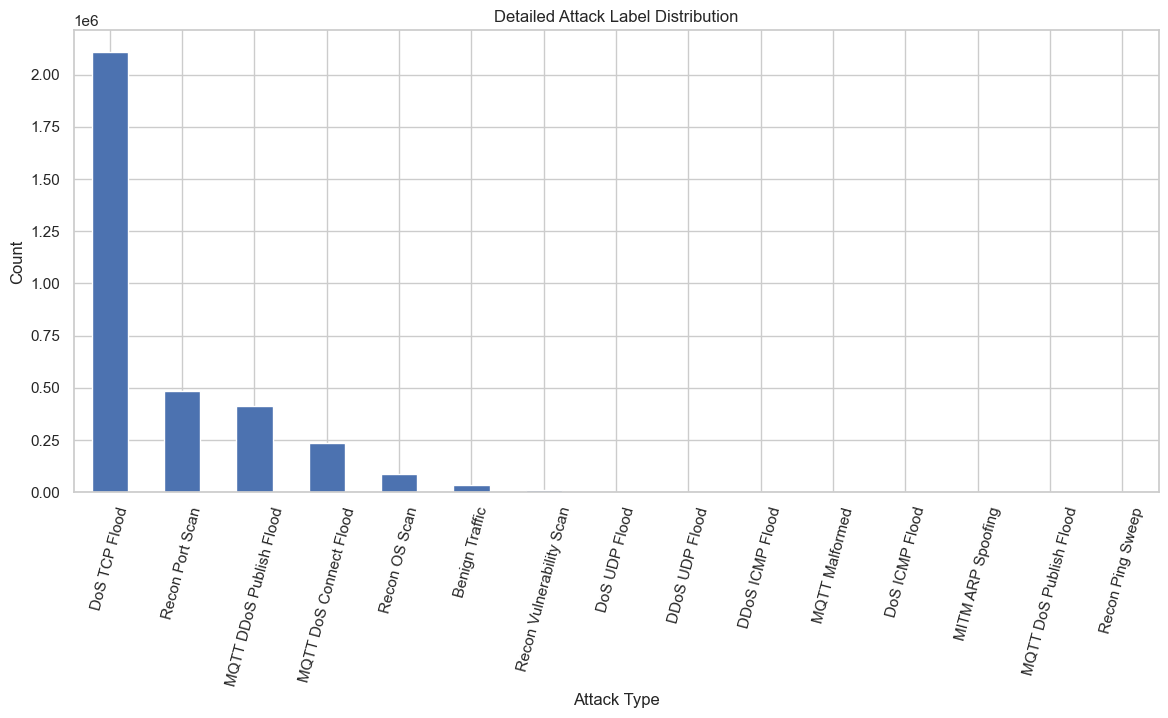

In [15]:
plt.figure(figsize=(14, 6))
full_counts.plot(kind="bar")
plt.title("Detailed Attack Label Distribution")
plt.ylabel("Count")
plt.xlabel("Attack Type")
plt.xticks(rotation=75)
plt.show()

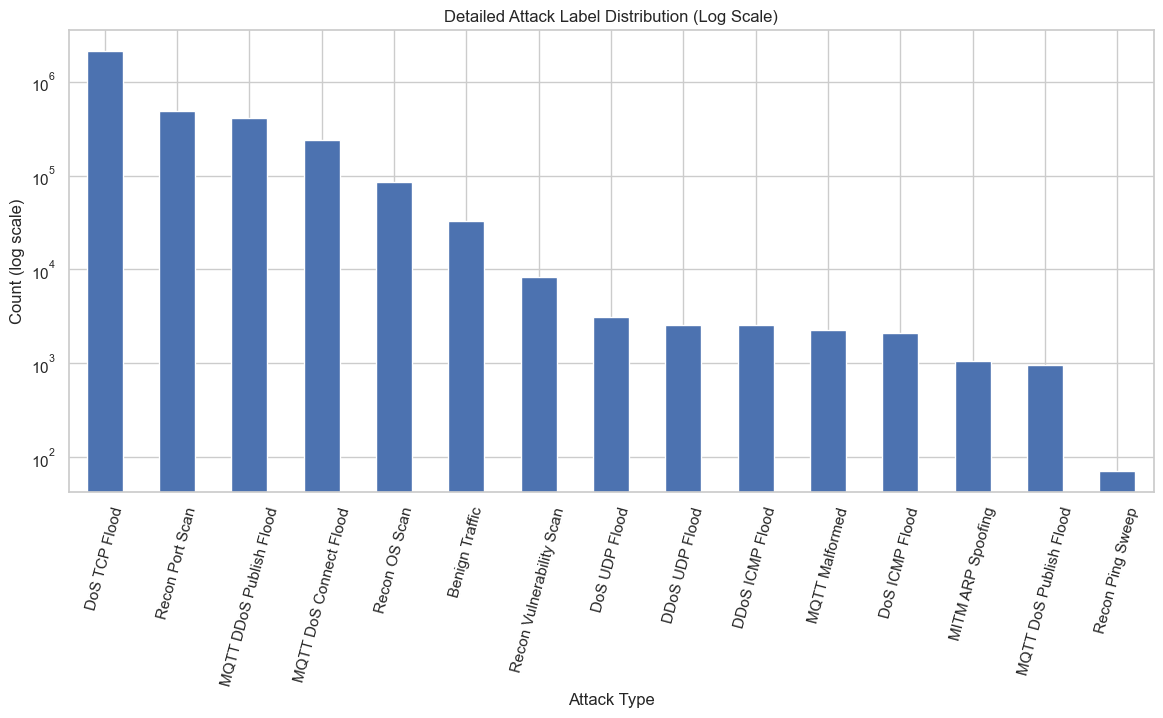

In [16]:
plt.figure(figsize=(14, 6))
full_counts.plot(kind="bar", logy=True)
plt.title("Detailed Attack Label Distribution (Log Scale)")
plt.ylabel("Count (log scale)")
plt.xlabel("Attack Type")
plt.xticks(rotation=75)
plt.show()

9. Descriptive statistics for numeric features

## Descriptive statistics
This section summarizes the numeric predictors.

In [15]:
numeric_df = df.select_dtypes(include=[np.number])
print("Numeric dataframe shape:", numeric_df.shape)
numeric_df.describe().T.head(20)

Numeric dataframe shape: (3385313, 81)


,count,mean,std,min,25%,50%,75%,max
Src Port,3385313.0,2.815707e+04,2.087252e+04,0.000000,6637.000000,2.800000e+04,4.661500e+04,6.553500e+04
Dst Port,3385313.0,2.078631e+04,2.191193e+04,1.000000,6668.000000,6.668000e+03,4.534900e+04,6.548700e+04
Protocol,3385313.0,6.000000e+00,0.000000e+00,6.000000,6.000000,6.000000e+00,6.000000e+00,6.000000e+00
Flow Duration,3385313.0,5.981806e+07,5.448959e+07,0.000000,292811.000000,5.882047e+07,1.182908e+08,1.200000e+08
Total Fwd Packet,3385313.0,1.607318e+01,8.220720e+01,1.000000,2.000000,9.000000e+00,3.000000e+01,3.187200e+04
Total Bwd packets,3385313.0,2.052150e+00,6.685132e+01,0.000000,0.000000,0.000000e+00,1.000000e+00,9.890000e+03
Total Length of Fwd Packet,3385313.0,7.097450e+02,6.113499e+04,0.000000,0.000000,0.000000e+00,0.000000e+00,4.614014e+07
Total Length of Bwd Packet,3385313.0,4.429530e+02,3.543056e+04,0.000000,0.000000,0.000000e+00,0.000000e+00,1.389573e+07
Fwd Packet Length Max,3385313.0,1.755943e+01,1.495838e+02,0.000000,0.000000,0.000000e+00,0.000000e+00,1.460000e+03
Fwd Packet Length Min,3385313.0,4.264957e+00,6.303575e+01,0.000000,0.000000,0.000000e+00,0.000000e+00,1.460000e+03


In [16]:
numeric_summary = numeric_df.describe().T
numeric_summary[["mean", "std", "min", "25%", "50%", "75%", "max"]].head(25)

,mean,std,min,25%,50%,75%,max
Src Port,2.815707e+04,2.087252e+04,0.000000e+00,6637.000000,2.800000e+04,4.661500e+04,6.553500e+04
Dst Port,2.078631e+04,2.191193e+04,1.000000e+00,6668.000000,6.668000e+03,4.534900e+04,6.548700e+04
Protocol,6.000000e+00,0.000000e+00,6.000000e+00,6.000000,6.000000e+00,6.000000e+00,6.000000e+00
Flow Duration,5.981806e+07,5.448959e+07,0.000000e+00,292811.000000,5.882047e+07,1.182908e+08,1.200000e+08
Total Fwd Packet,1.607318e+01,8.220720e+01,1.000000e+00,2.000000,9.000000e+00,3.000000e+01,3.187200e+04
Total Bwd packets,2.052150e+00,6.685132e+01,0.000000e+00,0.000000,0.000000e+00,1.000000e+00,9.890000e+03
Total Length of Fwd Packet,7.097450e+02,6.113499e+04,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,4.614014e+07
Total Length of Bwd Packet,4.429530e+02,3.543056e+04,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,1.389573e+07
Fwd Packet Length Max,1.755943e+01,1.495838e+02,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,1.460000e+03
Fwd Packet Length Min,4.264957e+00,6.303575e+01,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,1.460000e+03


10. Feature variance check

## Low-variance feature inspection
Features with zero or near-zero variance may have limited predictive usefulness.

In [17]:
feature_only_cols = [
    col for col in numeric_df.columns
    if col not in ["Label", "target_binary"]
]

variance_df = pd.DataFrame({
    "feature": feature_only_cols,
    "variance": [df[col].var() for col in feature_only_cols]
}).sort_values("variance")

variance_df.head(20)

,feature,variance
2,Protocol,0.000000
59,Fwd Bulk Rate Avg,0.000000
35,Bwd URG Flags,0.000000
57,Fwd Bytes/Bulk Avg,0.000000
58,Fwd Packet/Bulk Avg,0.000000
33,Bwd PSH Flags,0.000000
34,Fwd URG Flags,0.000015
50,URG Flag Count,0.000110
52,ECE Flag Count,0.000178
51,CWR Flag Count,0.000201


In [18]:
zero_variance_features = variance_df[variance_df["variance"] == 0]
zero_variance_features

,feature,variance
2,Protocol,0.0
59,Fwd Bulk Rate Avg,0.0
35,Bwd URG Flags,0.0
57,Fwd Bytes/Bulk Avg,0.0
58,Fwd Packet/Bulk Avg,0.0
33,Bwd PSH Flags,0.0


11. Correlation analysis

## Correlation analysis
The correlation matrix helps identify strongly related network-flow features.

In [19]:
corr_matrix = df[feature_only_cols].corr()
print(corr_matrix.shape)

(79, 79)


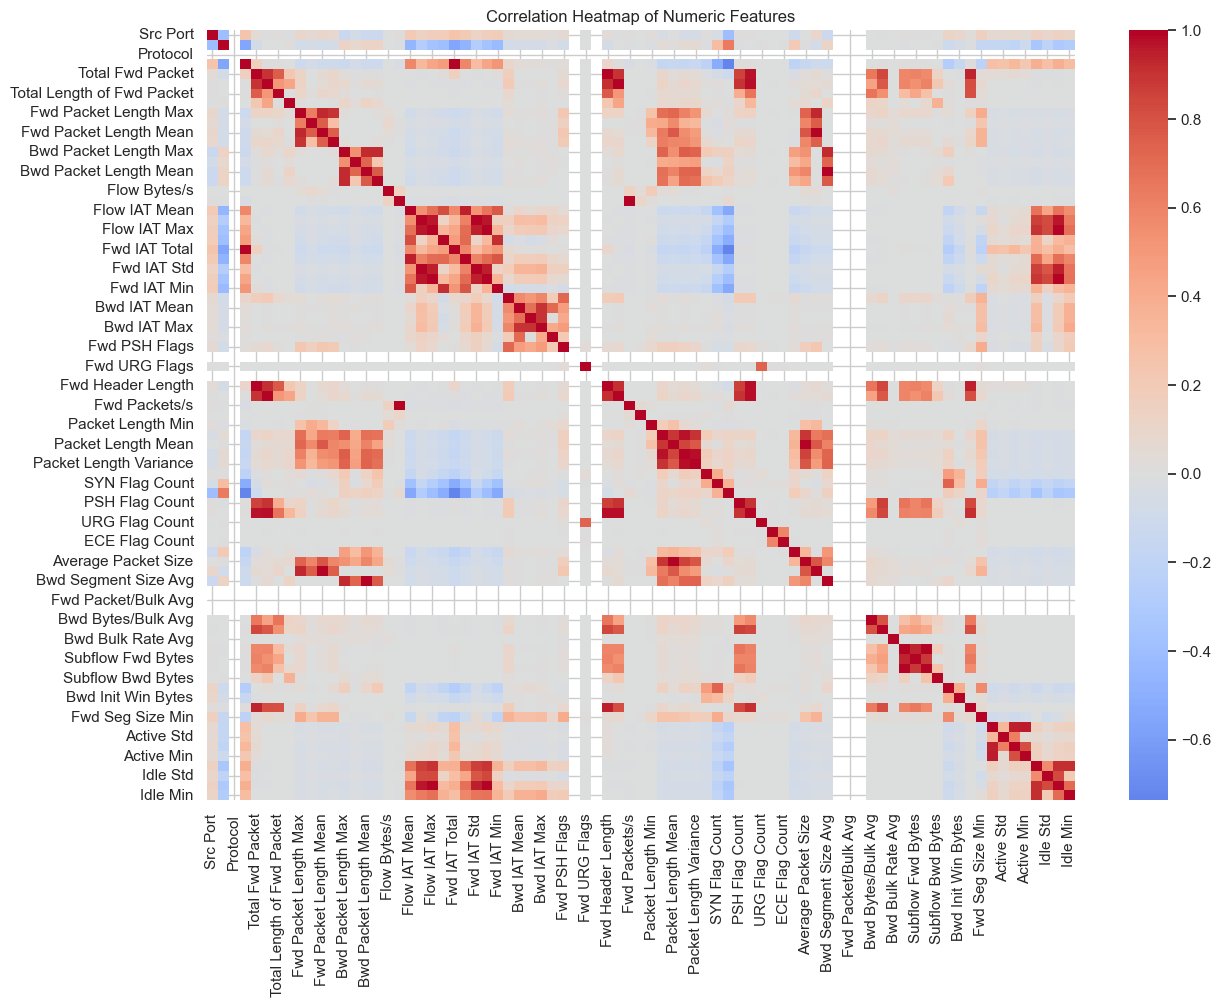

In [20]:
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

Because the full heatmap is crowded, we also inspect strongest correlations.

In [21]:
corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]
corr_pairs.head(30)

Bwd Segment Size Avg    Bwd Packet Length Mean    1.000000
Bwd Packet Length Mean  Bwd Segment Size Avg      1.000000
Total Bwd packets       Bwd Header Length         0.999931
Bwd Header Length       Total Bwd packets         0.999931
Flow Duration           Fwd IAT Total             0.998352
Fwd IAT Total           Flow Duration             0.998352
Flow Packets/s          Fwd Packets/s             0.998286
Fwd Packets/s           Flow Packets/s            0.998286
Total Fwd Packet        Fwd Header Length         0.997758
Fwd Header Length       Total Fwd Packet          0.997758
Average Packet Size     Packet Length Mean        0.996488
Packet Length Mean      Average Packet Size       0.996488
Flow IAT Max            Fwd IAT Max               0.994827
Fwd IAT Max             Flow IAT Max              0.994827
Idle Max                Flow IAT Max              0.992351
Flow IAT Max            Idle Max                  0.992351
Subflow Bwd Packets     Subflow Fwd Packets       0.9900

12. Top correlated feature pairs

In [22]:
corr_df = corr_matrix.abs().unstack().reset_index()
corr_df.columns = ["feature_1", "feature_2", "correlation"]
corr_df = corr_df[corr_df["feature_1"] != corr_df["feature_2"]]

corr_df["pair_key"] = corr_df.apply(
    lambda row: "_".join(sorted([row["feature_1"], row["feature_2"]])),
    axis=1
)

corr_df = corr_df.drop_duplicates("pair_key").sort_values("correlation", ascending=False)
corr_df[["feature_1", "feature_2", "correlation"]].head(20)

,feature_1,feature_2,correlation
845,Fwd Packet Length Mean,Fwd Segment Size Avg,1.000000
1162,Bwd Packet Length Mean,Bwd Segment Size Avg,1.000000
432,Total Bwd packets,Bwd Header Length,0.999931
259,Flow Duration,Fwd IAT Total,0.998352
1381,Flow Packets/s,Fwd Packets/s,0.998286
352,Total Fwd Packet,Fwd Header Length,0.997758
3372,Packet Length Mean,Average Packet Size,0.996488
1605,Flow IAT Max,Fwd IAT Max,0.994827
1657,Flow IAT Max,Idle Max,0.992351
5042,Subflow Fwd Packets,Subflow Bwd Packets,0.990049


In [23]:
high_corr_pairs = corr_df[corr_df["correlation"] >= 0.95][["feature_1", "feature_2", "correlation"]]
high_corr_pairs

,feature_1,feature_2,correlation
845,Fwd Packet Length Mean,Fwd Segment Size Avg,1.000000
1162,Bwd Packet Length Mean,Bwd Segment Size Avg,1.000000
432,Total Bwd packets,Bwd Header Length,0.999931
259,Flow Duration,Fwd IAT Total,0.998352
1381,Flow Packets/s,Fwd Packets/s,0.998286
352,Total Fwd Packet,Fwd Header Length,0.997758
3372,Packet Length Mean,Average Packet Size,0.996488
1605,Flow IAT Max,Fwd IAT Max,0.994827
1657,Flow IAT Max,Idle Max,0.992351
5042,Subflow Fwd Packets,Subflow Bwd Packets,0.990049


13. Select a few important features for visual inspection

## Selected feature distributions
A subset of numeric features is visualized to compare their distributions across classes.

In [24]:
candidate_features = [
    "Flow Duration",
    "Total Fwd Packet",
    "Total Bwd packets",
    "Flow Byts/s",
    "Flow Packets/s",
    "Packet Length Mean",
    "Packet Length Std",
    "SYN Flag Count",
    "ACK Flag Count",
    "Idle Mean"
]

selected_features = [col for col in candidate_features if col in df.columns]
selected_features

['Flow Duration',
 'Total Fwd Packet',
 'Total Bwd packets',
 'Flow Packets/s',
 'Packet Length Mean',
 'Packet Length Std',
 'SYN Flag Count',
 'ACK Flag Count',
 'Idle Mean']

14. Histograms of selected features

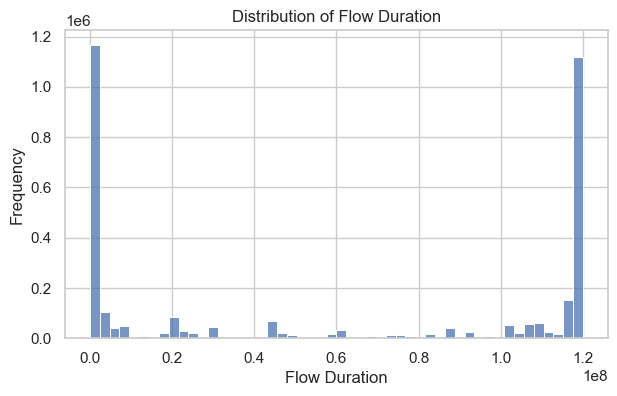

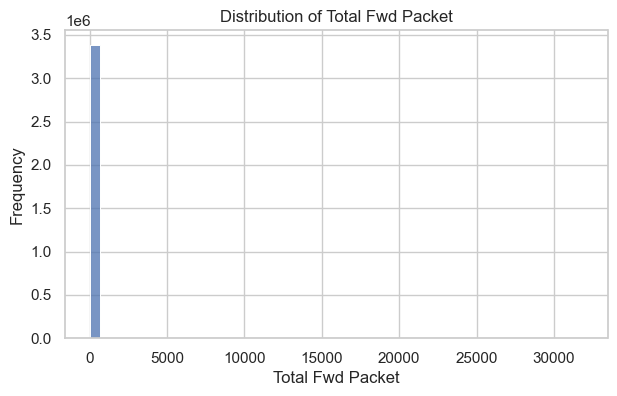

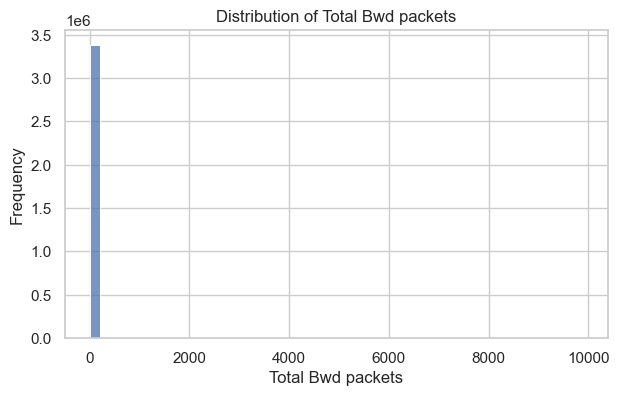

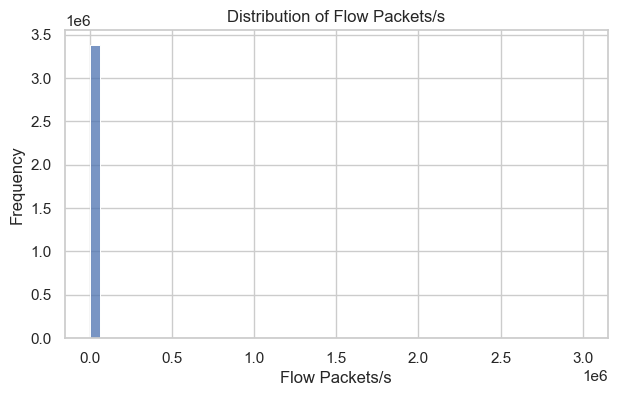

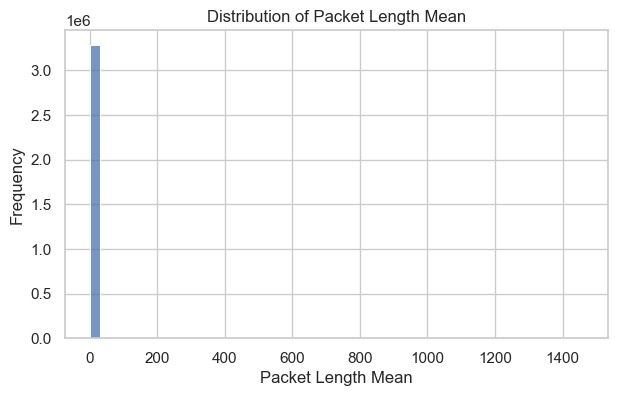

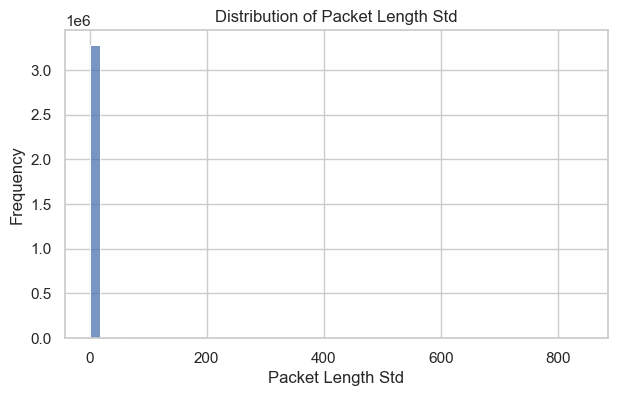

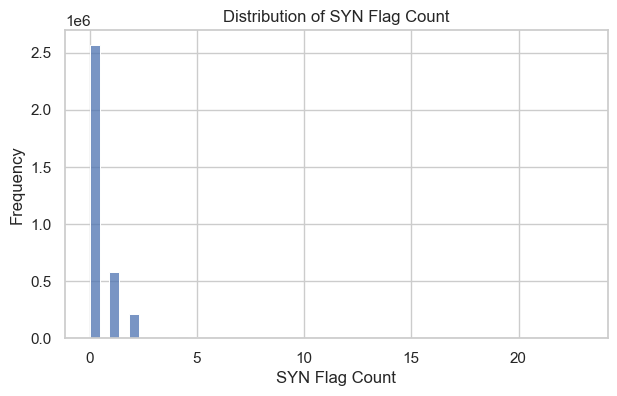

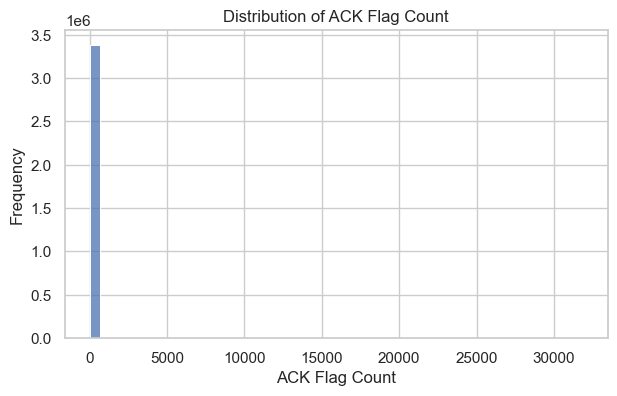

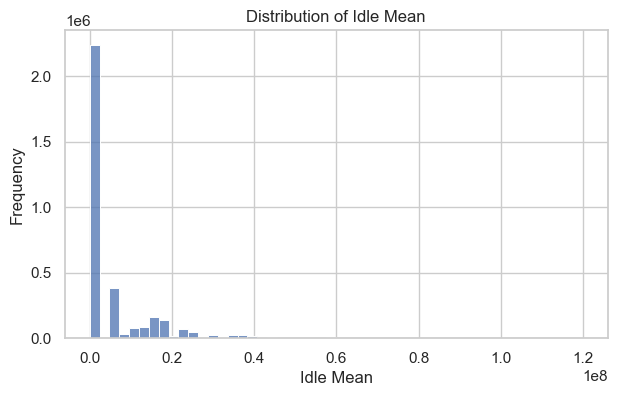

In [27]:
for col in selected_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], bins=50, kde=False)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

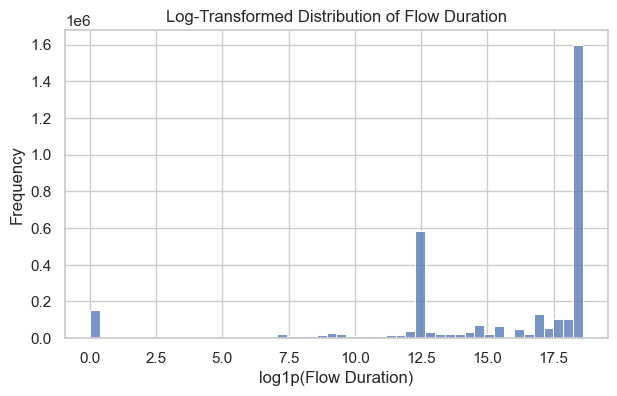

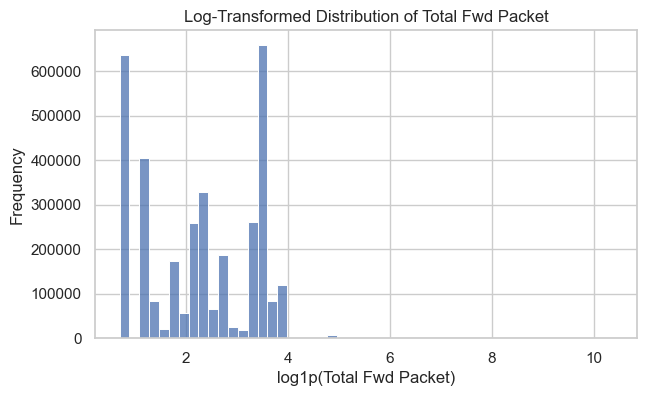

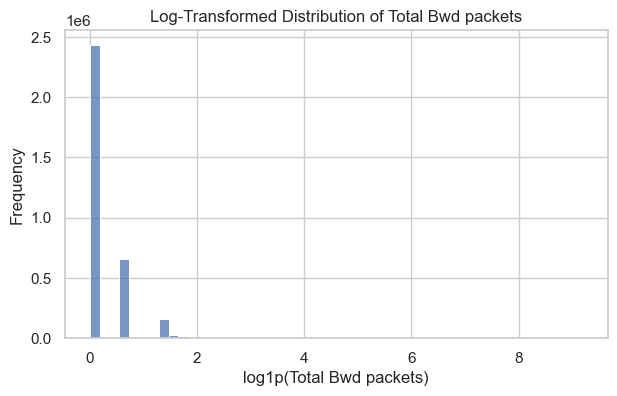

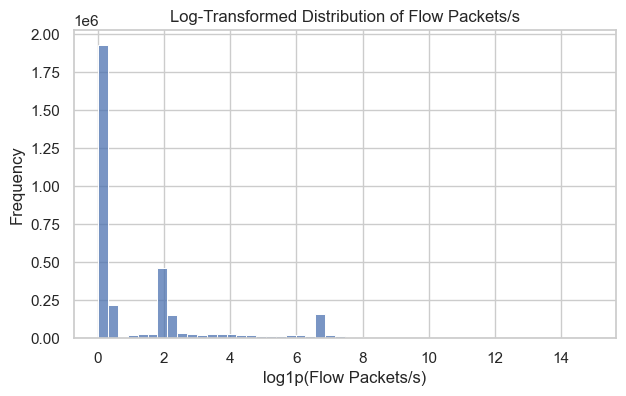

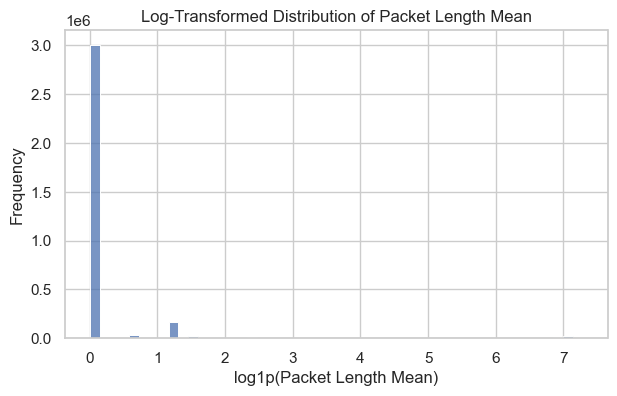

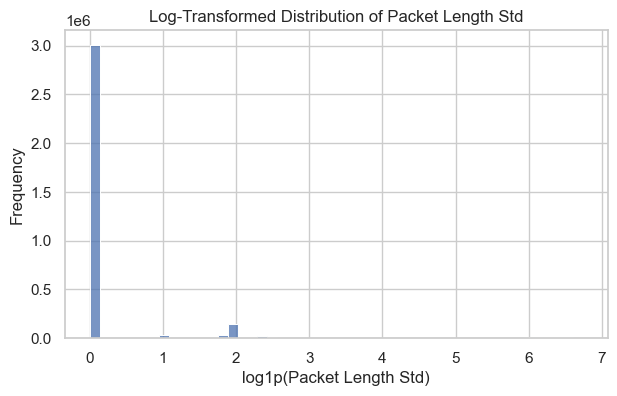

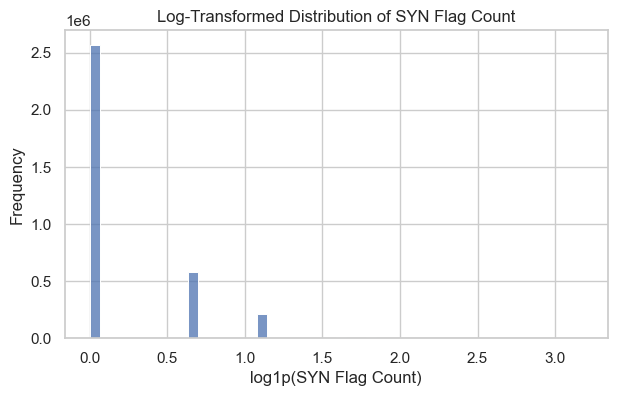

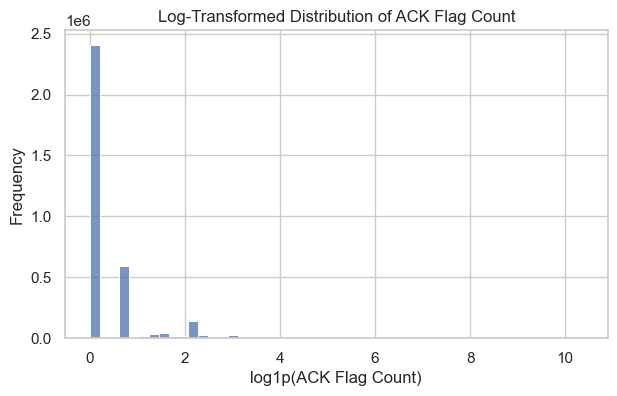

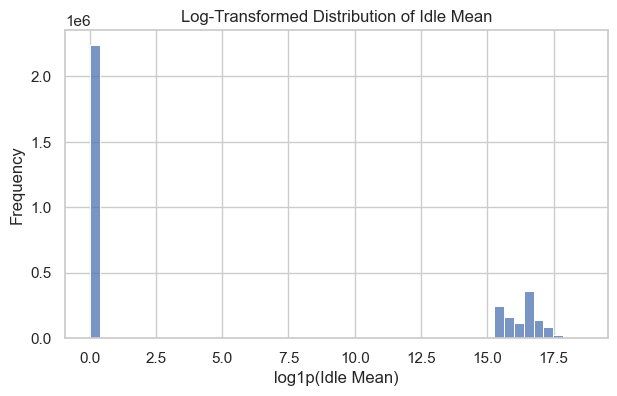

In [28]:
for col in selected_features:
    if (df[col] >= 0).all():
        plt.figure(figsize=(7, 4))
        sns.histplot(np.log1p(df[col]), bins=50, kde=False)
        plt.title(f"Log-Transformed Distribution of {col}")
        plt.xlabel(f"log1p({col})")
        plt.ylabel("Frequency")
        plt.show()

15. Compare selected features by grouped class

## Feature comparison by grouped attack category
The following boxplots help compare selected features across broader attack categories.

In [25]:
eda_sample = df.sample(n=min(100000, len(df)), random_state=42).copy()
print("EDA sample shape:", eda_sample.shape)

EDA sample shape: (100000, 91)


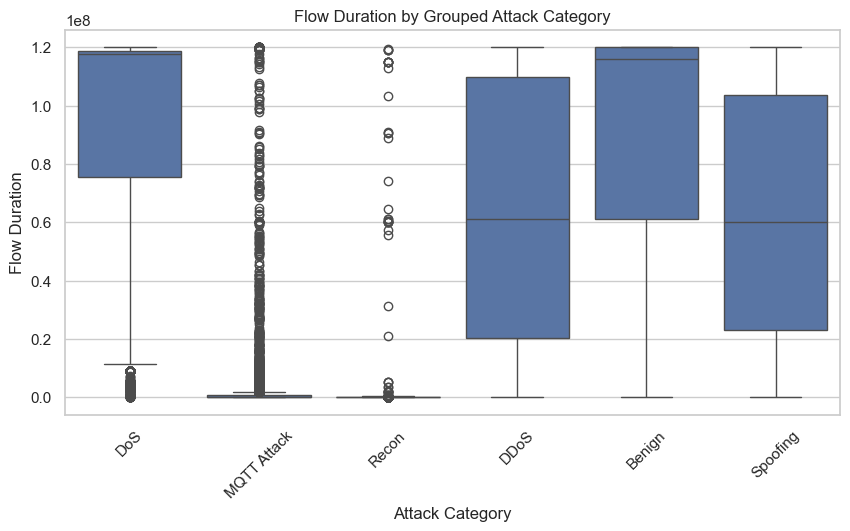

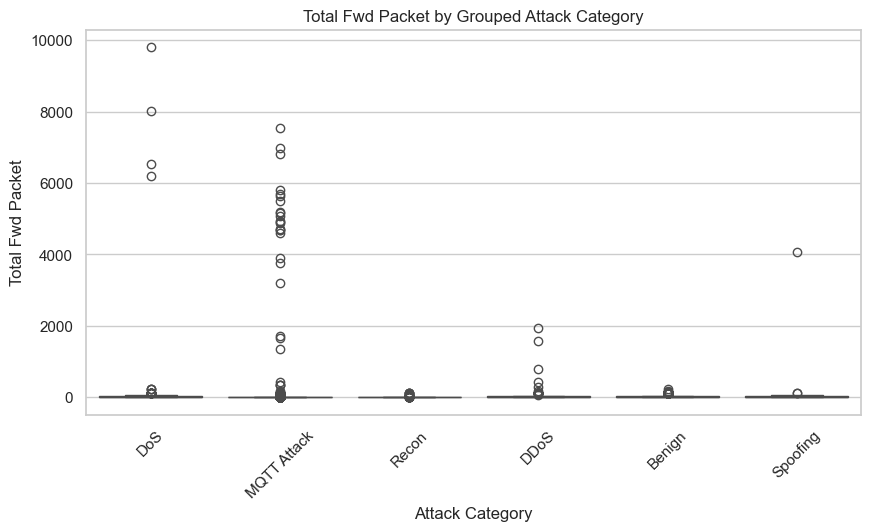

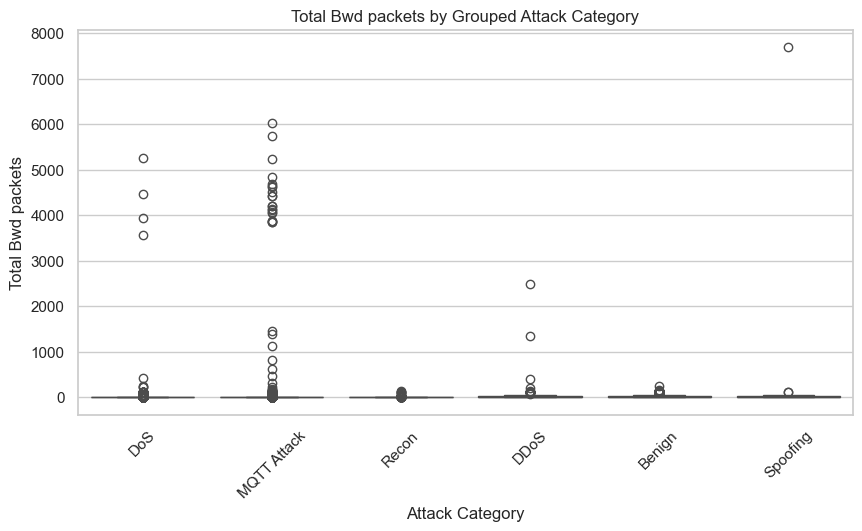

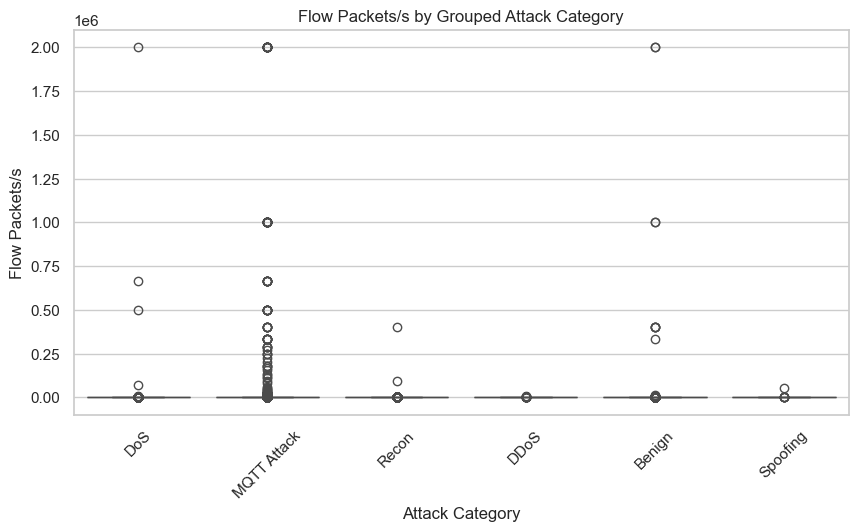

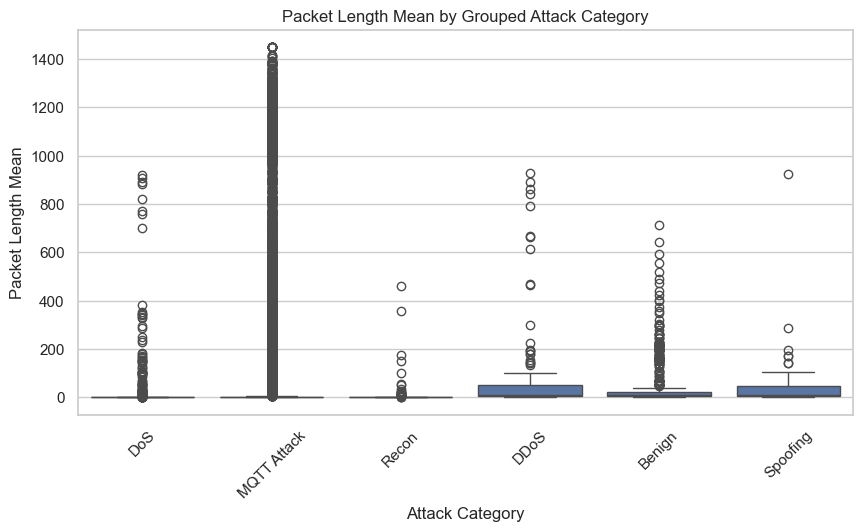

In [30]:
for col in selected_features[:5]:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=eda_sample, x="target_multiclass_grouped", y=col)
    plt.title(f"{col} by Grouped Attack Category")
    plt.xlabel("Attack Category")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.show()

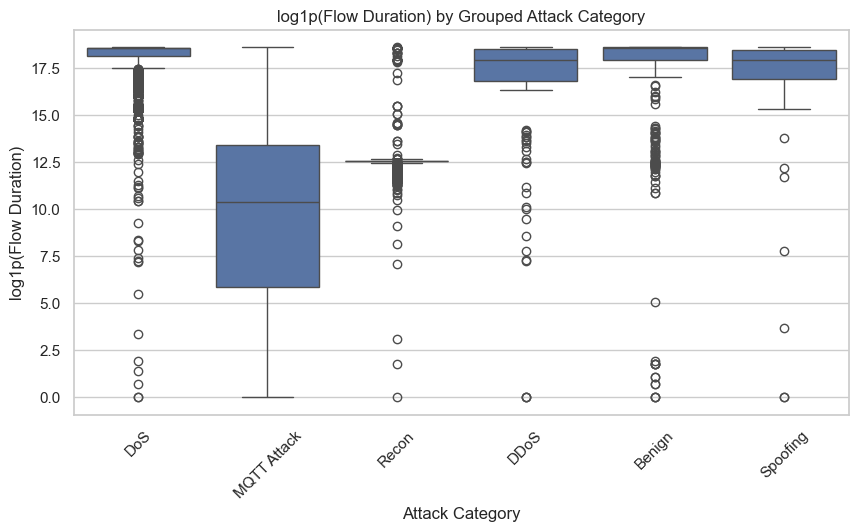

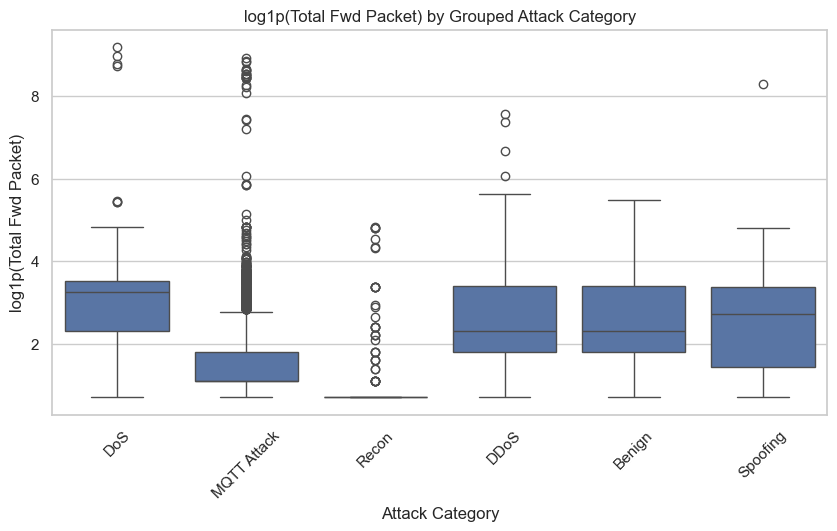

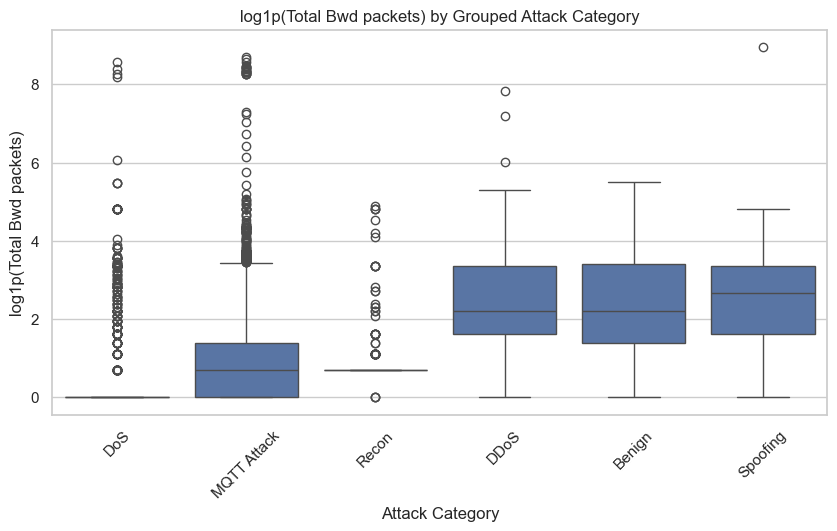

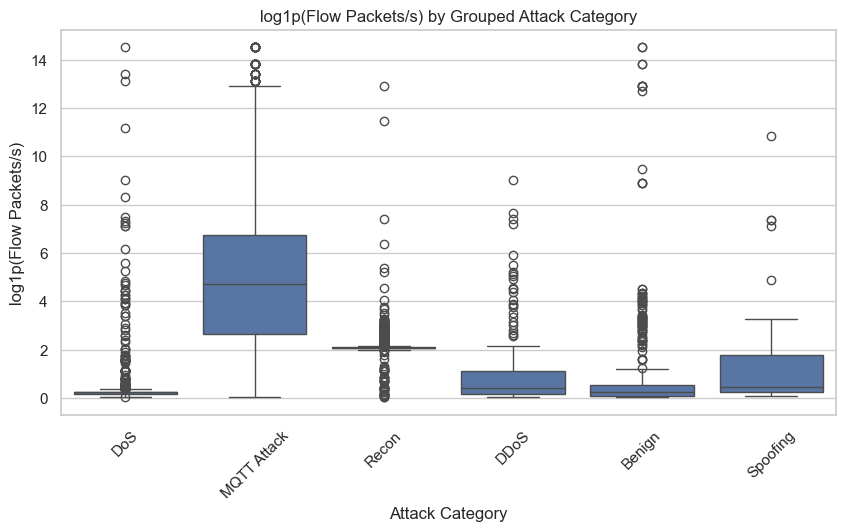

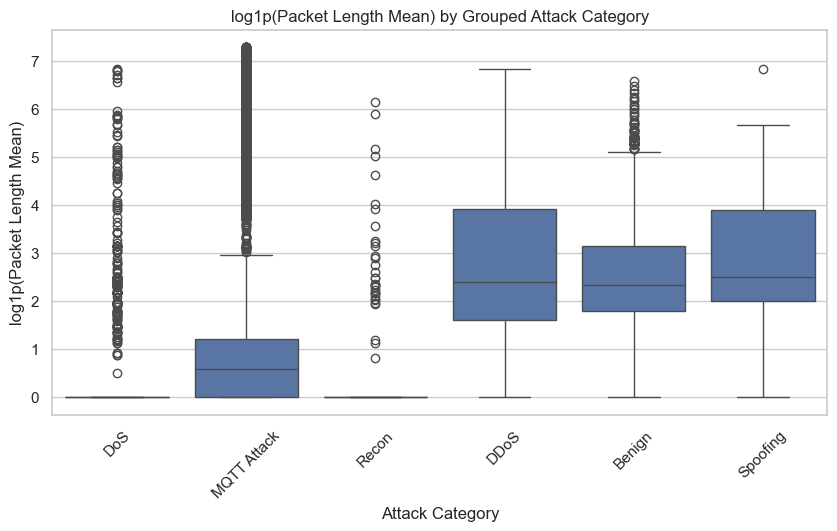

In [31]:
for col in selected_features[:5]:
    if (eda_sample[col] >= 0).all():
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=eda_sample, x="target_multiclass_grouped", y=np.log1p(eda_sample[col]))
        plt.title(f"log1p({col}) by Grouped Attack Category")
        plt.xlabel("Attack Category")
        plt.ylabel(f"log1p({col})")
        plt.xticks(rotation=45)
        plt.show()

16. Mean feature values by grouped class

## Mean feature values by grouped class
This section compares the average values of selected flow features across grouped attack categories.

In [26]:
group_feature_means = df.groupby("target_multiclass_grouped")[selected_features].mean()
group_feature_means

,Flow Duration,Total Fwd Packet,Total Bwd packets,Flow Packets/s,Packet Length Mean,Packet Length Std,SYN Flag Count,ACK Flag Count,Idle Mean
target_multiclass_grouped,,,,,,,,,
Benign,9.393253e+07,34.264255,28.763090,6617.761134,42.122400,53.859938,0.149142,62.968486,2.333959e+07
DDoS,6.410686e+07,66.587754,73.409321,1703.058048,58.949056,69.923348,0.570593,139.580538,1.671906e+07
DoS,9.369605e+07,21.955323,0.183787,33.854515,0.173363,0.212243,0.002225,0.431033,7.666706e+06
MQTT Attack,1.369165e+06,9.045991,6.990362,4713.550822,93.936612,62.923930,0.777722,14.417017,5.651480e+05
Recon,4.324653e+05,1.063981,1.059491,71.661922,0.104947,0.160022,0.999365,1.123124,3.969399e+04
Spoofing,6.033601e+07,36.268756,48.351377,1402.261527,51.337069,69.913517,0.342830,84.270655,1.628889e+07


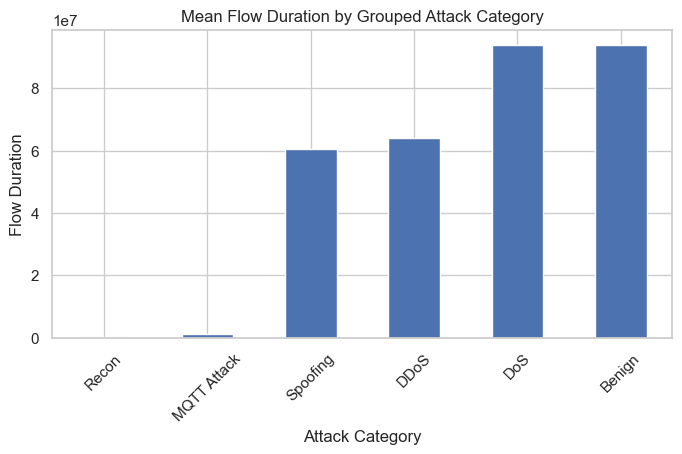

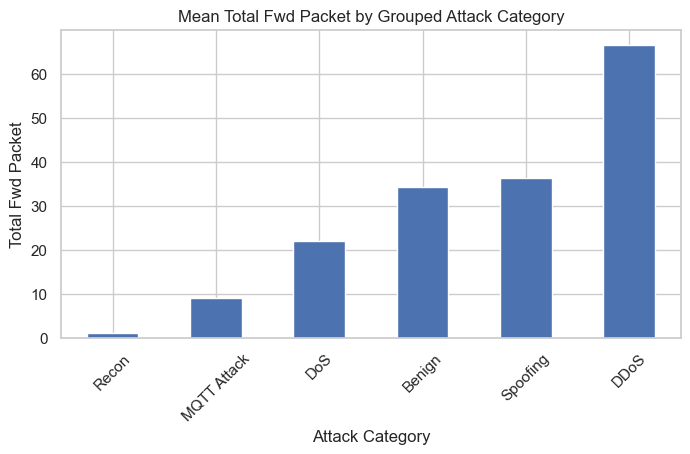

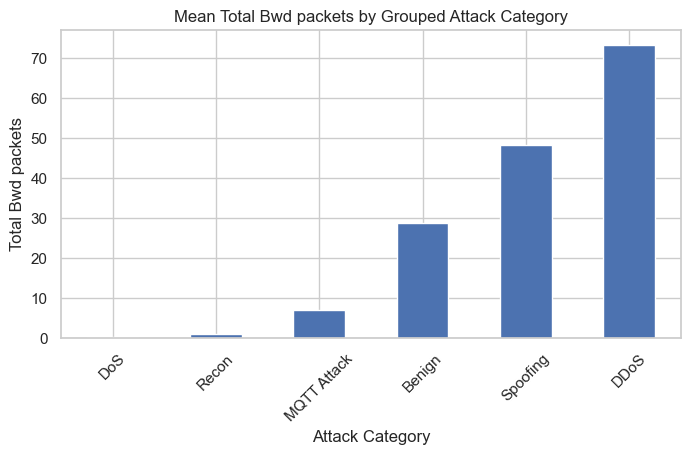

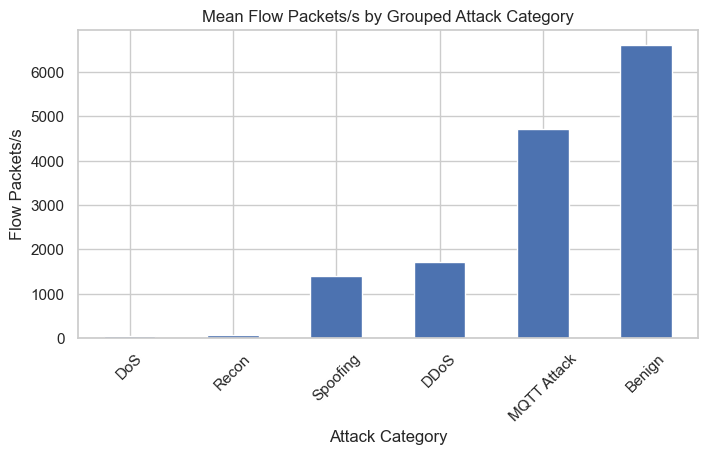

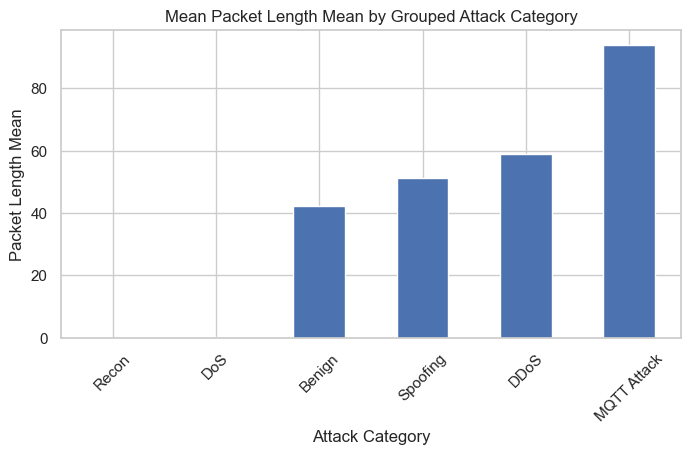

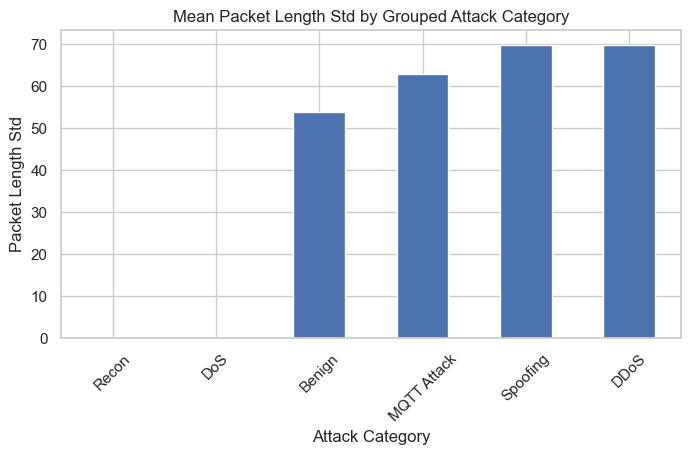

In [33]:
for col in selected_features[:6]:
    plt.figure(figsize=(8, 4))
    group_feature_means[col].sort_values().plot(kind="bar")
    plt.title(f"Mean {col} by Grouped Attack Category")
    plt.ylabel(col)
    plt.xlabel("Attack Category")
    plt.xticks(rotation=45)
    plt.show()

17. Distribution of packet and byte features by binary target

## Feature comparison by binary target
Selected features are also compared between benign and attack traffic.

In [27]:
binary_sample = df.sample(n=min(100000, len(df)), random_state=42).copy()
binary_sample["binary_label"] = binary_sample["target_binary"].map({0: "Benign", 1: "Attack"})

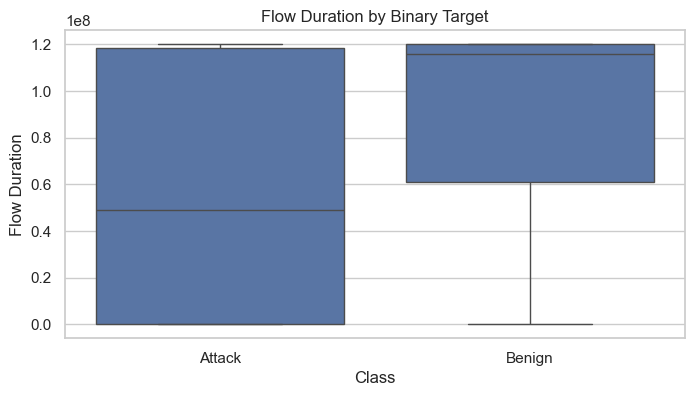

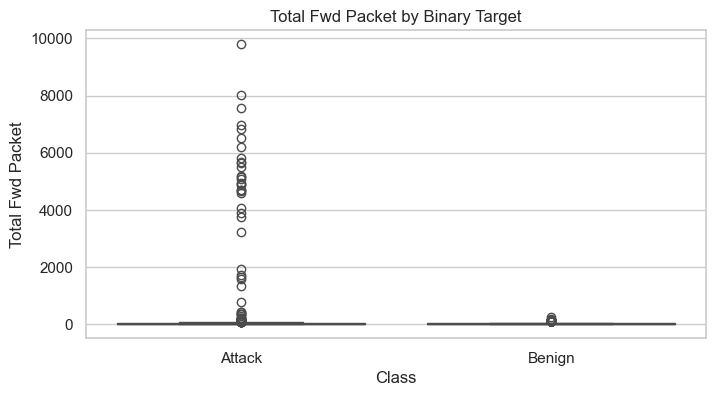

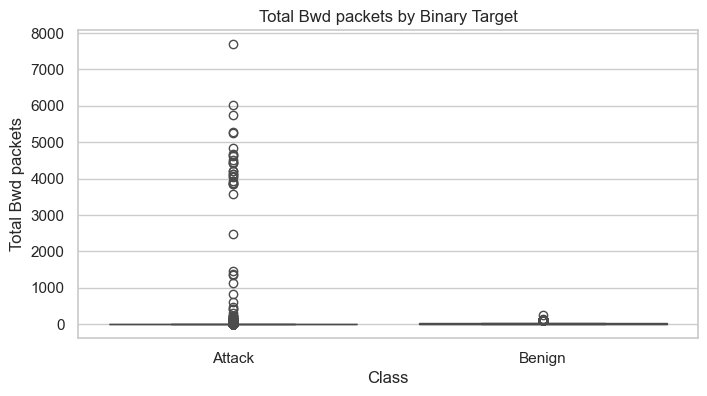

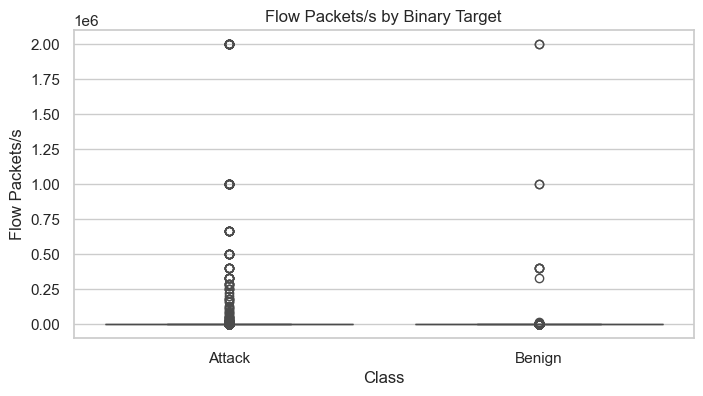

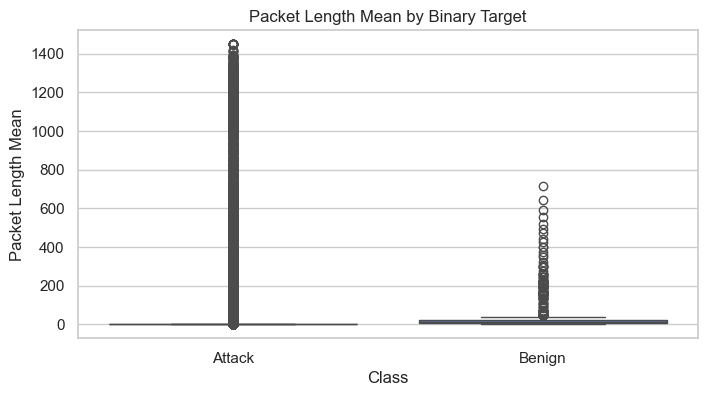

In [35]:
for col in selected_features[:5]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=binary_sample, x="binary_label", y=col)
    plt.title(f"{col} by Binary Target")
    plt.xlabel("Class")
    plt.ylabel(col)
    plt.show()

18. PCA preview

## PCA projection
A principal component analysis preview is used to inspect whether some attack categories show separability in lower-dimensional space.

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [32]:
pca_features = [col for col in feature_only_cols if df[col].nunique() > 1]
pca_sample = (
    df.groupby("target_multiclass_grouped", group_keys=False)
      .apply(lambda x: x.sample(min(len(x), 1000), random_state=42))
      .reset_index(drop=True)
)

X_pca = pca_sample[pca_features].copy()
y_pca = pca_sample["target_multiclass_grouped"].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

pca = PCA(n_components=2, random_state=42)
X_pca_2d = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "Attack Category": y_pca
})

pca_df.head()

C:\Users\jpetr\AppData\Local\Temp\ipykernel_15620\602849880.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 1000), random_state=42))


,PC1,PC2,Attack Category
0,-4.410998,5.176509,Benign
1,1.560627,0.330437,Benign
2,6.948580,4.485057,Benign
3,-2.001545,7.415075,Benign
4,0.019201,0.123982,Benign


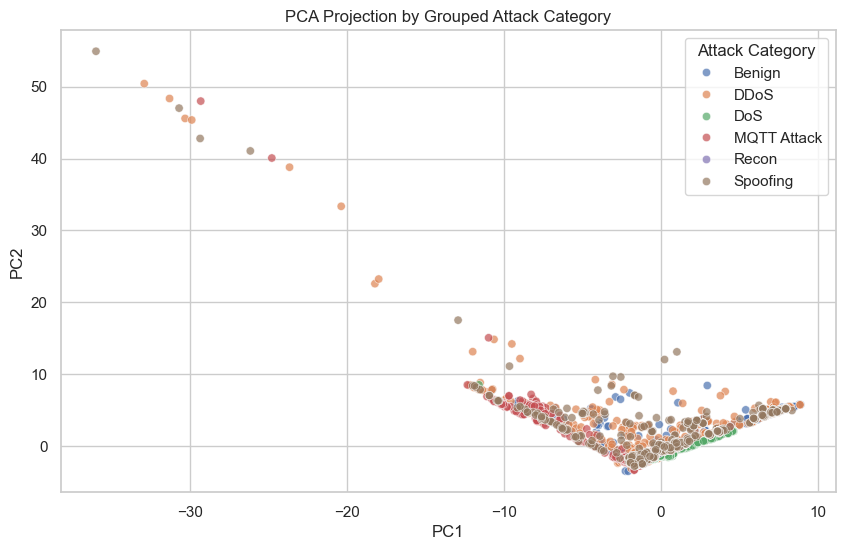

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Attack Category",
    alpha=0.7
)
plt.title("PCA Projection by Grouped Attack Category")
plt.show()

In [34]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.17070003 0.15371927]
Total explained variance: 0.3244192976888891


19. Outlier inspection with IQR summary

## Outlier inspection
Flow-based cybersecurity features often contain heavy skewness and extreme values. This section provides a simple outlier summary using the IQR rule.

In [35]:
outlier_summary = []

for col in selected_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    outlier_summary.append({
        "feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "outlier_count": outliers,
        "outlier_percentage": 100 * outliers / len(df)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("outlier_percentage", ascending=False)
outlier_df

,feature,Q1,Q3,IQR,outlier_count,outlier_percentage
6,SYN Flag Count,0.000000,0.000000e+00,0.000000e+00,816905,24.130856
3,Flow Packets/s,0.253305,6.864384e+00,6.611079e+00,479867,14.174967
8,Idle Mean,0.000000,6.260323e+06,6.260323e+06,453575,13.398318
4,Packet Length Mean,0.000000,0.000000e+00,0.000000e+00,379801,11.219081
5,Packet Length Std,0.000000,0.000000e+00,0.000000e+00,376861,11.132235
7,ACK Flag Count,0.000000,1.000000e+00,1.000000e+00,366498,10.826119
2,Total Bwd packets,0.000000,1.000000e+00,1.000000e+00,281092,8.303279
1,Total Fwd Packet,2.000000,3.000000e+01,2.800000e+01,7691,0.227187
0,Flow Duration,292811.000000,1.182908e+08,1.179980e+08,0,0.000000


20. Benign vs Attack mean comparison

## Benign vs Attack mean comparison
A simple mean comparison helps reveal whether selected features differ substantially between benign and attack traffic.

In [36]:
binary_feature_means = df.groupby("target_binary")[selected_features].mean()
binary_feature_means.index = ["Benign", "Attack"]
binary_feature_means

,Flow Duration,Total Fwd Packet,Total Bwd packets,Flow Packets/s,Packet Length Mean,Packet Length Std,SYN Flag Count,ACK Flag Count,Idle Mean
Benign,9.393253e+07,34.264255,28.763090,6617.761134,42.122400,53.859938,0.149142,62.968486,2.333959e+07
Attack,5.948614e+07,15.896187,1.792266,957.819253,18.589598,12.586102,0.327011,3.522739,4.977871e+06


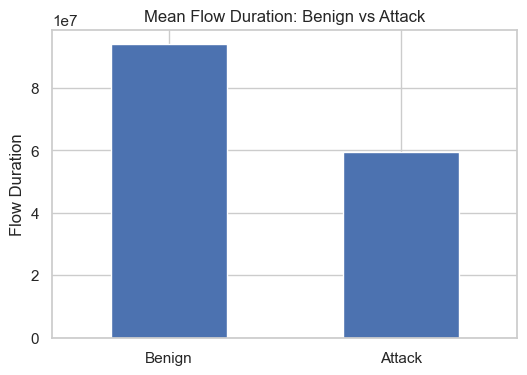

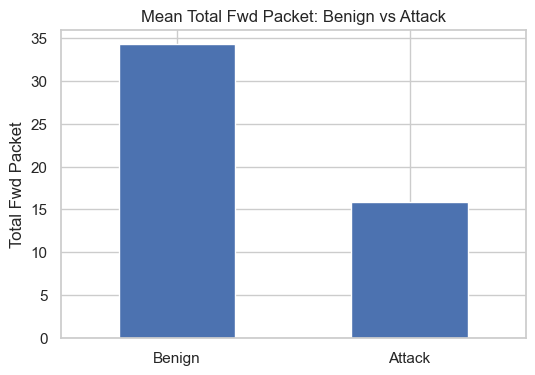

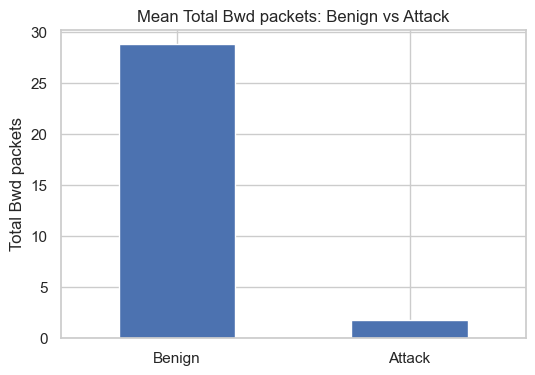

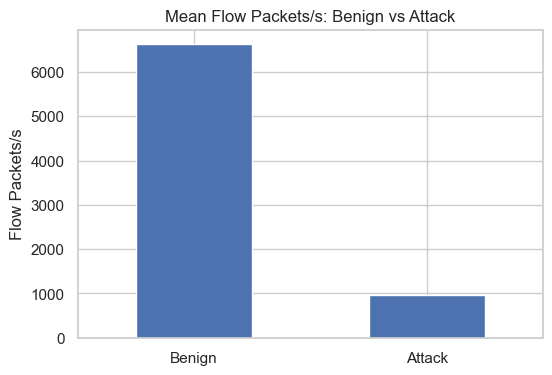

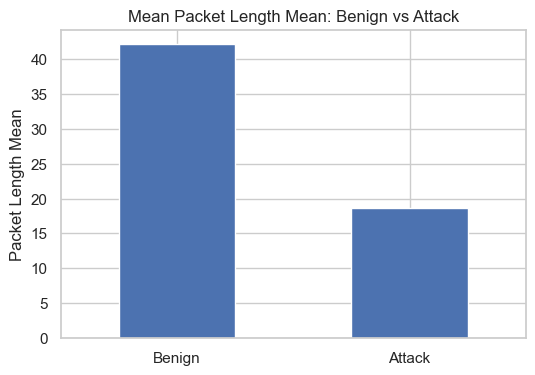

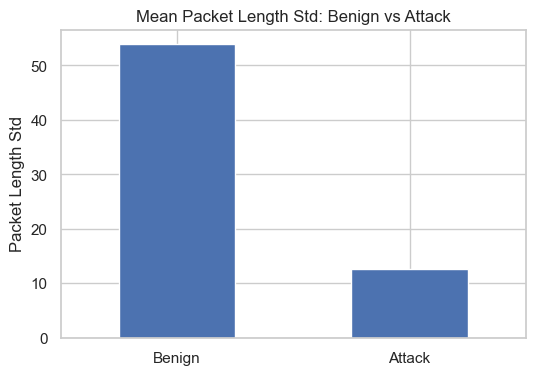

In [37]:
for col in selected_features[:6]:
    plt.figure(figsize=(6, 4))
    binary_feature_means[col].plot(kind="bar")
    plt.title(f"Mean {col}: Benign vs Attack")
    plt.ylabel(col)
    plt.xticks(rotation=0)
    plt.show()

21. Crosstab of source files and attack labels

## Source-file verification
This section verifies the relationship between source files and attack labels.

In [38]:
if "source_file" in df.columns:
    source_attack_crosstab = pd.crosstab(df["source_file"], df["attack_label"])
    source_attack_crosstab

22. Key EDA findings table

## Key findings table
The following table summarizes the main observations from the exploratory analysis.

In [39]:
eda_findings = pd.DataFrame({
    "Finding": [
        "Missing values",
        "Infinite values",
        "Binary class imbalance",
        "Multiclass imbalance",
        "Grouped attack categories available",
        "High skewness expected in flow features",
        "Potential multicollinearity present",
        "PCA used for separability preview"
    ],
    "Observation": [
        "No missing values detected",
        "No infinite values detected",
        "Attack traffic heavily dominates benign traffic",
        "Some attack classes are extremely rare compared with others",
        "Yes",
        "Yes, especially in packet, byte, and duration features",
        "Likely, based on strong feature correlations",
        "Yes"
    ]
})

eda_findings

,Finding,Observation
0,Missing values,No missing values detected
1,Infinite values,No infinite values detected
2,Binary class imbalance,Attack traffic heavily dominates benign traffic
3,Multiclass imbalance,Some attack classes are extremely rare compare...
4,Grouped attack categories available,Yes
5,High skewness expected in flow features,"Yes, especially in packet, byte, and duration ..."
6,Potential multicollinearity present,"Likely, based on strong feature correlations"
7,PCA used for separability preview,Yes


24. Final summary

## Summary of findings

The exploratory data analysis confirmed that the CICIoMT2024 dataset is structurally clean, with no missing values and no infinite values, but exhibits severe class imbalance in both the binary and multiclass settings. Attack traffic dominates benign traffic, and several detailed attack classes contain substantially fewer observations than the majority classes.

The numeric flow features show wide variation in scale and appear to include strong skewness and potential outliers, which is typical in network-traffic datasets. Correlation analysis also suggests that several predictors may be highly related, indicating possible multicollinearity.

Visual comparisons across grouped attack categories and the PCA projection provide an initial indication that some attack families may be separable in feature space, although overlap is still expected. These findings support the next stage of the project, which will focus on preprocessing, train-test splitting, scaling strategies, and model-ready feature preparation.

25. Export of summary tables

In [ ]:
REPORT_DIR = Path("../reports/results")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

numeric_summary.to_csv(REPORT_DIR / "eda_numeric_summary.csv")
variance_df.to_csv(REPORT_DIR / "eda_feature_variance.csv", index=False)
corr_df[["feature_1", "feature_2", "correlation"]].to_csv(REPORT_DIR / "eda_top_correlations.csv", index=False)
outlier_df.to_csv(REPORT_DIR / "eda_outlier_summary.csv", index=False)
eda_findings.to_csv(REPORT_DIR / "eda_findings_summary.csv", index=False)

print("EDA summary tables exported.")